<a href="https://colab.research.google.com/github/FossegrimRora/Subject-1/blob/main/Fathir_Putra_H.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahdimashayekhi/disease-risk-from-daily-habits")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'disease-risk-from-daily-habits' dataset.
Path to dataset files: /kaggle/input/disease-risk-from-daily-habits


In [ ]:
!pip install catboost

In [ ]:
#import library
import pandas as pd
import os

# Lihat isi folder dataset
print(os.listdir(path))

['health_lifestyle_classification.csv']


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from catboost import CatBoostClassifier

In [ ]:
df = pd.read_csv(path + "/health_lifestyle_classification.csv")
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 11  heart_rate                85997 non-null   float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000 non-null  fl

In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [ ]:
df.isnull().sum()

,0
survey_code,0
age,0
gender,0
height,0
weight,0
bmi,0
bmi_estimated,0
bmi_scaled,0
bmi_corrected,0
waist_size,0


In [ ]:
df = df.drop(columns=[
'survey_code',
'bmi_estimated',
'bmi_scaled',
'bmi_corrected',
'mental_health_score',
'mental_health_support',
'education_level',
'job_type',
'occupation',
'income',
'healthcare_access',
'insurance',
'sunlight_exposure',
'family_history',
'pet_owner',
'electrolyte_level',
'gene_marker_flag',
'environmental_risk_score',
'daily_supplement_dosage'
])

df.columns

Index(['age', 'gender', 'height', 'weight', 'bmi', 'waist_size',
       'blood_pressure', 'heart_rate', 'cholesterol', 'glucose', 'insulin',
       'sleep_hours', 'sleep_quality', 'work_hours', 'physical_activity',
       'daily_steps', 'calorie_intake', 'sugar_intake', 'alcohol_consumption',
       'smoking_level', 'water_intake', 'screen_time', 'stress_level',
       'diet_type', 'exercise_type', 'device_usage', 'meals_per_day',
       'caffeine_intake', 'target'],
      dtype='object')

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
bmi,0
waist_size,0
blood_pressure,0
heart_rate,0
cholesterol,0
glucose,0


In [ ]:
df['target'] = df['target'].map({
    'healthy':0,
    'diseased':1
})



df['target'].value_counts()

,count
target,
0,70097
1,29903


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
cat_features = X.select_dtypes(include='object').columns.tolist()

print(cat_features)

['gender', 'sleep_quality', 'alcohol_consumption', 'smoking_level', 'diet_type', 'exercise_type', 'device_usage', 'caffeine_intake']


In [ ]:
df['insulin'] = df['insulin'].clip(lower=0)

In [ ]:
df['sugar_intake'] = df['sugar_intake'].clip(lower=0)

In [ ]:
df.describe()

,age,height,weight,bmi,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,water_intake,screen_time,stress_level,meals_per_day,target
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,48.525990,170.023707,70.064862,24.493876,84.933043,119.977974,74.979964,189.966438,99.994538,14.988967,7.002008,8.001331,3.038344,7012.206098,2201.428579,60.054597,2.006373,6.021525,4.991600,2.998720,0.299030
std,17.886768,9.982798,14.693667,5.951069,12.040314,14.428246,9.219394,29.981934,19.982828,4.584308,1.496821,1.994723,1.884475,2383.082319,400.516318,19.942291,0.688868,2.933835,3.154997,1.414786,0.457835
min,18.000000,140.000000,40.000000,9.988495,34.093185,59.128168,34.745092,58.410902,12.434931,0.000000,3.000000,0.000000,0.000000,1000.000000,527.172360,0.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,33.000000,163.306615,59.856938,20.271405,76.795185,110.815119,69.543894,169.667738,86.461401,12.324714,5.986781,6.651093,1.633799,5500.327842,1932.278165,46.504292,1.532011,3.971318,2.000000,2.000000,0.000000
50%,48.000000,170.016778,69.924141,24.156734,84.957139,119.951794,75.046211,190.044579,99.986834,14.983414,6.998164,8.004549,2.971222,7004.285450,2200.992765,60.047905,2.000659,5.991171,5.000000,3.000000,0.000000
75%,64.000000,176.728920,80.027418,28.258696,93.018713,129.185145,80.467128,210.222005,113.508722,17.663430,8.019219,9.353669,4.326500,8523.819577,2471.218160,73.476386,2.473047,8.024470,8.000000,4.000000,1.000000
max,79.000000,210.000000,139.250894,59.234792,133.153631,184.439195,114.136041,319.875613,183.883548,35.464749,12.000000,16.000000,11.631898,18064.969543,3949.019017,141.514522,5.000000,16.000000,10.000000,5.000000,1.000000


In [ ]:
df['target'].value_counts()
auto_class_weights="Balanced"


In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,age,gender,height,weight,bmi,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,diet_type,exercise_type,device_usage,meals_per_day,caffeine_intake,target
0,56,Male,173.416872,56.886640,18.915925,72.165130,118.264254,60.749825,214.580523,103.008176,14.983414,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,Unknown,Non-smoker,1.694262,5.003963,2,Vegan,Strength,High,5,Moderate,0
1,69,Female,163.207380,97.799859,36.716278,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,Vegan,Cardio,Moderate,5,High,0
2,46,Male,177.281966,80.687562,25.673050,90.295030,123.073698,76.043212,138.134787,89.180302,14.983414,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,Vegan,Cardio,High,4,Moderate,0
3,32,Female,172.101255,63.142868,21.318480,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,Vegetarian,Mixed,Low,1,Unknown,0
4,60,Female,163.608816,40.000000,14.943302,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,Unknown,Heavy,1.968393,3.180087,9,Vegan,Unknown,Low,1,High,0


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
bmi,0
waist_size,0
blood_pressure,0
heart_rate,0
cholesterol,0
glucose,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80000, 28)
X_test: (20000, 28)
y_train: (80000,)
y_test: (20000,)


In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

target
0    56078
1    23922
Name: count, dtype: int64
target
0    14019
1     5981
Name: count, dtype: int64


In [ ]:
print(cat_features)

['gender', 'sleep_quality', 'alcohol_consumption', 'smoking_level', 'diet_type', 'exercise_type', 'device_usage', 'caffeine_intake']


In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    auto_class_weights="Balanced",
    verbose=200
)

In [ ]:
train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

[       age  gender      height      weight        bmi  waist_size  \
 28921   73    Male  185.651872   87.031403  25.250926   83.424851   
 86694   38  Female  175.614196   78.905492  25.585151   85.347841   
 17225   73  Female  165.706940   71.348072  25.983691   74.608313   
 9785    53    Male  169.169475   76.599754  26.765994   86.066034   
 42646   56  Female  170.848856   58.932800  20.189842   90.549734   
 ...    ...     ...         ...         ...        ...         ...   
 20538   76  Female  174.288586   61.260202  20.166964  101.305828   
 88526   74    Male  170.464809   40.000000  13.765453   75.511180   
 94876   76    Male  169.152019  100.764172  35.216952   86.740245   
 27826   60  Female  158.675351   62.161357  24.688889   68.471246   
 46459   38    Male  192.529868   40.000000  10.791051   75.371128   
 
        blood_pressure  heart_rate  cholesterol     glucose    insulin  \
 28921      101.854292   76.529278   230.426008   94.648026  20.567906   
 86694    

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    auto_class_weights="Balanced",
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_state=42,
    verbose=200
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=200
)

0:	learn: 0.5090043	test: 0.5010110	best: 0.5010110 (0)	total: 478ms	remaining: 15m 56s
200:	learn: 0.5841257	test: 0.5015251	best: 0.5040489 (181)	total: 40.7s	remaining: 6m 4s
400:	learn: 0.6533931	test: 0.5037289	best: 0.5060651 (390)	total: 1m 17s	remaining: 5m 7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5060651069
bestIteration = 390

Shrink model to first 391 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='Accuracy', iterations=2000, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=200)

In [ ]:
print(model)

CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='Accuracy', iterations=2000, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=200)


In [ ]:
model.get_best_iteration()

390

In [ ]:
import pandas as pd

feature_importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

print(importance_df)

                feature  importance
20         water_intake    6.321041
5            waist_size    6.246953
15          daily_steps    6.062889
2                height    5.686125
9               glucose    5.559545
21          screen_time    5.553663
17         sugar_intake    5.235626
8           cholesterol    5.223007
16       calorie_intake    5.089890
13           work_hours    5.077458
7            heart_rate    4.986416
6        blood_pressure    4.814224
3                weight    4.699161
11          sleep_hours    4.690410
0                   age    4.445584
4                   bmi    4.429563
10              insulin    4.233795
14    physical_activity    3.604314
22         stress_level    1.623702
26        meals_per_day    1.545332
18  alcohol_consumption    1.172576
1                gender    1.132998
12        sleep_quality    0.581819
27      caffeine_intake    0.523482
23            diet_type    0.431037
24        exercise_type    0.384350
25         device_usage    0

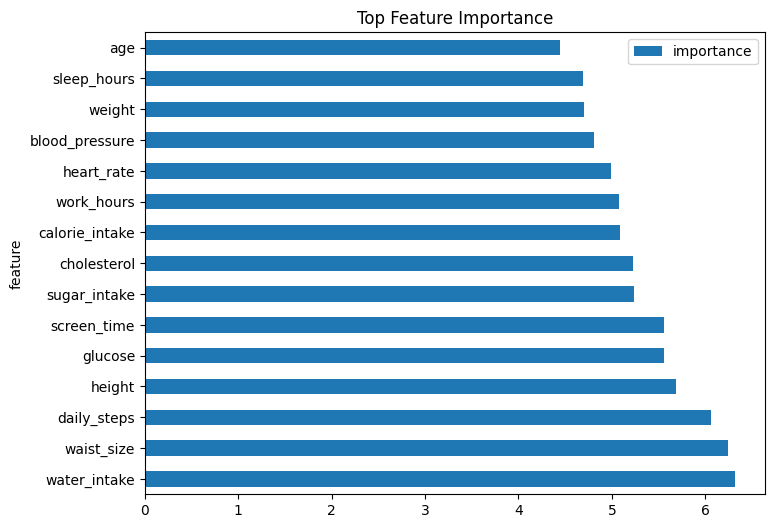

In [ ]:
import matplotlib.pyplot as plt

importance_df.head(15).plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,6)
)

plt.title("Top Feature Importance")
plt.show()

In [ ]:
import pandas as pd

corr = df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(corr)

target               1.000000
age                  0.006951
weight               0.002626
bmi                  0.002527
sleep_hours          0.001663
cholesterol          0.001529
waist_size           0.000553
glucose              0.000483
calorie_intake       0.000254
insulin              0.000137
screen_time          0.000134
heart_rate          -0.000055
sugar_intake        -0.000334
stress_level        -0.000767
physical_activity   -0.001298
height              -0.001453
water_intake        -0.001848
blood_pressure      -0.002537
meals_per_day       -0.002914
daily_steps         -0.004842
work_hours          -0.010906
Name: target, dtype: float64


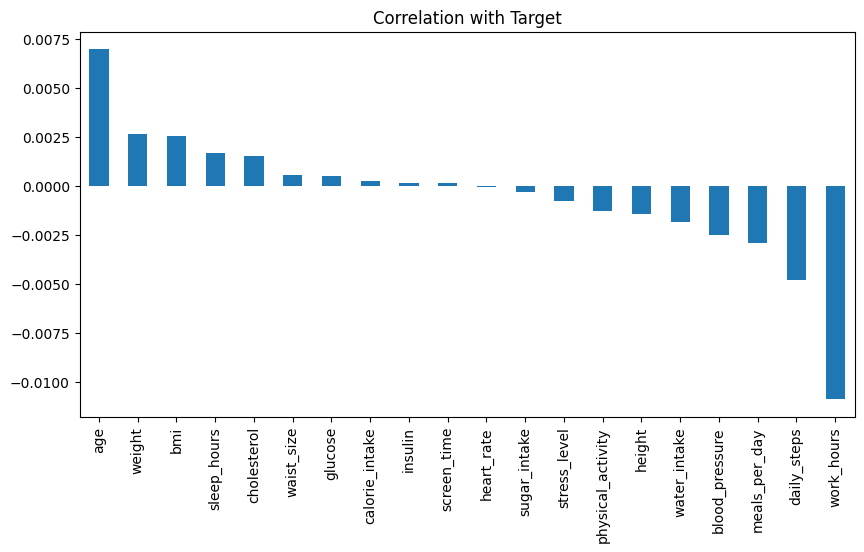

In [ ]:
import matplotlib.pyplot as plt

corr.drop('target').plot(kind='bar', figsize=(10,5))
plt.title("Correlation with Target")
plt.show()